# 6. Routing Simulation — What Would the Routing Change?

Stage 5 diagnosed a gap (collaboration reach tracks commercial concentration
but current priority barely does). This stage translates that gap into an
operational proposal and simulates its effect on the queue.

**Proposed rule**
- Hub + Premium/Enterprise + Low → Medium pilot queue
- Hub + Premium/Enterprise + Medium → High pilot queue
- Elevated → visible collaboration flag only
- Standard and existing High/Critical tickets → no change

For example, a technically Medium ticket remains **Medium severity**, but
its effective pilot queue becomes **High** when it belongs to an eligible
Hub customer.

**How to interpret this:** this is a feasibility simulation. A moved ticket
is not evidence of faster service, higher engagement, or additional
revenue — that's checked (and found currently unmeasurable) in stage 7.

In [1]:
from common import ARTIFACTS, BLUE, TEAL, GREY, PRIORITY_ORDER, save_show
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ticket_view = pd.read_parquet(ARTIFACTS / "ticket_view.parquet")
print(f"Loaded ticket_view: {len(ticket_view):,} rows.")

Loaded ticket_view: 8,469 rows.


## 6.1 Apply the Rule

In [2]:
ticket_view["effective_priority"] = ticket_view["ticket_priority"]
eligible = (
    ticket_view["collaboration_tier"].eq("Hub")
    & ticket_view["plan_type"].isin(["Premium", "Enterprise"])
    & ticket_view["ticket_priority"].isin(["Low", "Medium"])
)
ticket_view.loc[
    eligible & ticket_view["ticket_priority"].eq("Low"), "effective_priority"
] = "Medium"
ticket_view.loc[
    eligible & ticket_view["ticket_priority"].eq("Medium"), "effective_priority"
] = "High"
ticket_view["moved"] = ticket_view["effective_priority"].ne(ticket_view["ticket_priority"])

eligible_population = ticket_view[
    ticket_view["collaboration_tier"].eq("Hub")
    & ticket_view["plan_type"].isin(["Premium", "Enterprise"])
]
print(f"Eligible population (Hub + Premium/Enterprise): {len(eligible_population):,} tickets")
print(f"Tickets actually moved: {int(ticket_view['moved'].sum()):,}")

Eligible population (Hub + Premium/Enterprise): 232 tickets
Tickets actually moved: 125


## 6.2 Queue Composition Before/After

In [3]:
queue_composition = pd.DataFrame({
    "current": ticket_view["ticket_priority"].value_counts().reindex(PRIORITY_ORDER, fill_value=0),
    "simulated": ticket_view["effective_priority"].value_counts().reindex(PRIORITY_ORDER, fill_value=0),
})
queue_composition["change"] = queue_composition["simulated"] - queue_composition["current"]

moved_by_plan_priority = (
    ticket_view.loc[eligible]
    .groupby(["plan_type", "ticket_priority"], observed=True).size()
    .unstack(fill_value=0)
    .reindex(index=["Premium", "Enterprise"], columns=["Low", "Medium"], fill_value=0)
)
moved_by_type = ticket_view.loc[eligible, "ticket_type"].value_counts().sort_values()
print("Queue composition and move breakdowns computed.")

Queue composition and move breakdowns computed.


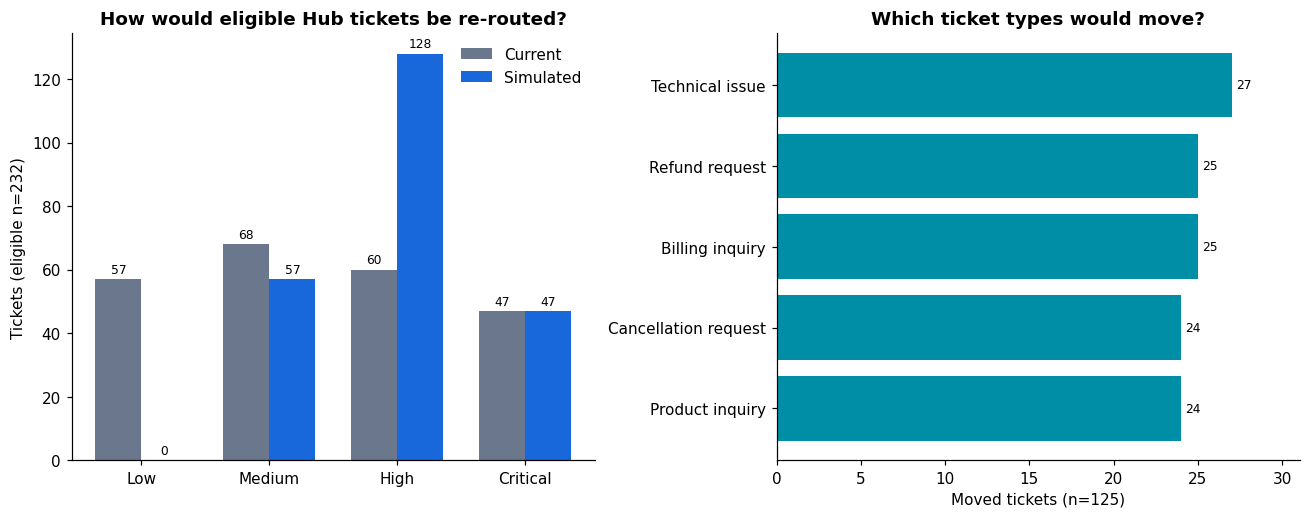

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.6), layout="constrained")
current_eligible = eligible_population["ticket_priority"].value_counts().reindex(PRIORITY_ORDER, fill_value=0)
simulated_eligible = eligible_population["effective_priority"].value_counts().reindex(PRIORITY_ORDER, fill_value=0)
x = np.arange(len(PRIORITY_ORDER))
width = .36
current_bars = axes[0].bar(x - width/2, current_eligible, width, color=GREY, label="Current")
simulated_bars = axes[0].bar(x + width/2, simulated_eligible, width, color=BLUE, label="Simulated")
axes[0].bar_label(current_bars, padding=2, fontsize=8)
axes[0].bar_label(simulated_bars, padding=2, fontsize=8)
axes[0].set(
    title="How would eligible Hub tickets be re-routed?",
    ylabel=f"Tickets (eligible n={len(eligible_population):,})",
    xticks=x, xticklabels=PRIORITY_ORDER,
)
axes[0].legend(frameon=False)

bars = axes[1].barh(moved_by_type.index, moved_by_type.values, color=TEAL)
axes[1].bar_label(bars, padding=3, fontsize=8)
axes[1].set(title="Which ticket types would move?", xlabel=f"Moved tickets (n={eligible.sum():,})")
axes[1].margins(x=.15)
save_show(fig, "07_routing_simulation.png")

In [5]:
display(Markdown("**Moved tickets by plan and original priority**"))
display(moved_by_plan_priority)
display(Markdown("**Overall queue composition**"))
display(queue_composition)

moved_count = int(ticket_view["moved"].sum())
moved_share = moved_count / len(ticket_view)
display(Markdown(f'''**Observed:** the rule moves **{moved_count:,}/{len(ticket_view):,} tickets
({moved_share:.2%})**. Existing Critical tickets are unchanged.

**Meaning:** the policy is narrow enough for a controlled pilot rather than a full queue redesign.

**Limitation:** movement is not improvement. The data does not show how waiting time or engagement
would respond.'''))

**Moved tickets by plan and original priority**

ticket_priority,Low,Medium
plan_type,,
Premium,34,30
Enterprise,23,38


**Overall queue composition**

,current,simulated,change
Low,2063,2006,-57
Medium,2192,2181,-11
High,2085,2153,68
Critical,2129,2129,0


**Observed:** the rule moves **125/8,469 tickets
(1.48%)**. Existing Critical tickets are unchanged.

**Meaning:** the policy is narrow enough for a controlled pilot rather than a full queue redesign.

**Limitation:** movement is not improvement. The data does not show how waiting time or engagement
would respond.

## 6.3 Save for Downstream Stages

In [6]:
ticket_view.to_parquet(ARTIFACTS / "ticket_view.parquet")
routing_results = {"moved_count": moved_count, "moved_share": moved_share}
with open(ARTIFACTS / "routing_results.json", "w") as f:
    json.dump(routing_results, f, indent=2)
print("Saved: ticket_view.parquet (with effective_priority/moved), routing_results.json -> ./artifacts/")

Saved: ticket_view.parquet (with effective_priority/moved), routing_results.json -> ./artifacts/
